In [ ]:
if ( ! require ( "dplyr" ))  install.packages ( "dplyr" )
install.packages ( 'nycflights13' )
#Librería de la BD
library ( nycflights13 )
library ( dplyr )

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
head(flights, 30) #air_time	distance
#head(weather) #Intresting humid, wind_dir,	wind_speed, temp
#head(planes) #X
#head(airports) #Xhead(airlines) #X

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
str(flights)

tibble [336,776 × 19] (S3: tbl_df/tbl/data.frame)
 $ year          : int [1:336776] 2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month         : int [1:336776] 1 1 1 1 1 1 1 1 1 1 ...
 $ day           : int [1:336776] 1 1 1 1 1 1 1 1 1 1 ...
 $ dep_time      : int [1:336776] 517 533 542 544 554 554 555 557 557 558 ...
 $ sched_dep_time: int [1:336776] 515 529 540 545 600 558 600 600 600 600 ...
 $ dep_delay     : num [1:336776] 2 4 2 -1 -6 -4 -5 -3 -3 -2 ...
 $ arr_time      : int [1:336776] 830 850 923 1004 812 740 913 709 838 753 ...
 $ sched_arr_time: int [1:336776] 819 830 850 1022 837 728 854 723 846 745 ...
 $ arr_delay     : num [1:336776] 11 20 33 -18 -25 12 19 -14 -8 8 ...
 $ carrier       : chr [1:336776] "UA" "UA" "AA" "B6" ...
 $ flight        : int [1:336776] 1545 1714 1141 725 461 1696 507 5708 79 301 ...
 $ tailnum       : chr [1:336776] "N14228" "N24211" "N619AA" "N804JB" ...
 $ origin        : chr [1:336776] "EWR" "LGA" "JFK" "JFK" ...
 $ dest          : ch

In [ ]:
summary(flights)

      year          month             day           dep_time    sched_dep_time
 Min.   :2013   Min.   : 1.000   Min.   : 1.00   Min.   :   1   Min.   : 106  
 1st Qu.:2013   1st Qu.: 4.000   1st Qu.: 8.00   1st Qu.: 907   1st Qu.: 906  
 Median :2013   Median : 7.000   Median :16.00   Median :1401   Median :1359  
 Mean   :2013   Mean   : 6.549   Mean   :15.71   Mean   :1349   Mean   :1344  
 3rd Qu.:2013   3rd Qu.:10.000   3rd Qu.:23.00   3rd Qu.:1744   3rd Qu.:1729  
 Max.   :2013   Max.   :12.000   Max.   :31.00   Max.   :2400   Max.   :2359  
                                                 NA's   :8255                 
   dep_delay          arr_time    sched_arr_time   arr_delay       
 Min.   : -43.00   Min.   :   1   Min.   :   1   Min.   : -86.000  
 1st Qu.:  -5.00   1st Qu.:1104   1st Qu.:1124   1st Qu.: -17.000  
 Median :  -2.00   Median :1535   Median :1556   Median :  -5.000  
 Mean   :  12.64   Mean   :1502   Mean   :1536   Mean   :   6.895  
 3rd Qu.:  11.00   3rd Qu.:1

**COCIENTE DE VARIANZAS**

In [ ]:
#Instalación del paquete stests
if (!require('devtools')) install.packages('devtools')
devtools::install_github('fhernanb/stests', force=TRUE)

Loading required package: devtools

Loading required package: usethis




HDInterval (NA -> 0.2.4) [CRAN]
expm       (NA -> 1.0-0) [CRAN]


Installing 2 packages: HDInterval, expm

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmp8HvhRQ/remotes2637339909d/fhernanb-stests-945d140/DESCRIPTION’ ... OK
* preparing ‘stests’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
Omitted ‘LazyData’ from DESCRIPTION
* building ‘stests_0.1.0.tar.gz’



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**Comparación de Varianzas de Distancias de Vuelo entre Aeropuertos JFK y LGA**


**PROBLEMA**

Con el objetivo de mejorar la eficiencia en la asignación de aeronaves y recursos, el equipo de logística de una aerolínea desea comparar la variabilidad en las distancias de vuelo de los aeropuertos JFK (John F. Kennedy) y LGA (LaGuardia). Según informes previos, se sospecha que los vuelos desde JFK tienen una mayor dispersión en las distancias recorridas, debido a una mayor diversidad de destinos internacionales y de largo alcance. Ambas poblaciones se asumen con distribución normal.




In [ ]:
# 1. Fijar semilla para reproducibilidad
set.seed(1000)

# 2. Filtrar vuelos según el origen JFK y LGA
JFK.flights <- subset(flights, origin == "JFK")   # Todos los vuelos desde JFK
LGA.flights <- subset(flights, origin == "LGA")   # Todos los vuelos desde LGA

# 3. Tomar una muestra aleatoria de 30 vuelos de cada uno con reemplazo
sample.JFK <- JFK.flights[sample(1:nrow(JFK.flights), 30, replace = T), ]
sample.LGA <- LGA.flights[sample(1:nrow(LGA.flights), 30, replace = T), ]

resultado.varianzas <- stests::var.test(sample.JFK$distance, sample.LGA$distance, conf.level = 0.95)$conf.int


# 5. Intervalo de confianza para el cociente de varianzas de distancia
cat("===== Intervalo de Confianza para eL COCIENTE DE VARIANZAS de los vuelos =====\n")
cat("IC 95%: [",resultado.varianzas,"]\n")

===== Intervalo de Confianza para eL COCIENTE DE VARIANZAS de los vuelos =====
IC 95%: [ 2.597424 11.46551 ]


**ANÁLISIS DEL COCIENTE DE VARIANZAS**

Para investigar esta diferencia, se recopilan dos muestras aleatorias de 30 vuelos con reemplazo desde una base de datos, seleccionando la variable distance de la base de datos flights del paquete nycflights13, que representa la distancia recorrida por cada vuelo en millas.
Bajo el supuesto de normalidad en ambas poblaciones, se aplica una prueba de cociente de varianzas con un nivel de confianza del 95%, utilizando la función var.test() de stests, para determinar si existe una diferencia estadísticamente significativa en la variabilidad entre ambos aeropuertos.




La prueba de cociente de varianzas arrojó un intervalo de confianza del 95% para el cociente de varianzas: [2.5974, 11.4655]. Como este intervalo se encuentra completamente por encima del valor 1, indica que la variabilidad en las distancias de vuelo desde JFK es significativamente mayor que la de los vuelos desde LGA.

Por lo tanto, se respalda con un 95% de confianza que la variabilidad de las distancias de vuelo desde JFK es mayor que la de LGA. Este hallazgo respalda lo asumido por el equipo logístico.

**UNA VARIANZA**

In [ ]:
# 1. Fijar semilla para reproducibilidad
set.seed(1000)

# 2. Filtrar vuelos según el origen EWR
EWR.flights <- subset(flights, origin == "EWR")   # Todos los vuelos desde EWR

# 3. Tomar una muestra aleatoria de 30 con reemplazo
sample.EWR <- EWR.flights[sample(1:nrow(EWR.flights), 30, replace = T), ]

resultado.varianza <-stests::var.test(sample.EWR$distance, conf.level = 0.95)$conf.int

#Utilización de la función varTest para calculo de intervalo de Varianza
cat("===== Intervalo de Confianza para la Varianza =====\n")
cat("IC 95%: [",resultado.varianza,"]\n")

===== Intervalo de Confianza para la Varianza =====
IC 95%: [ 220704.2 628843.8 ]




**PROBLEMA:**

Una compañía desea conocer la variabilidad de las distancias de vuelo desde el aeropuerto EWR, ya que esto influye en la logística de operaciones y asignación de recursos. Según sus estimaciones internas, se afirma que la varianza poblacional es aproximadamente 553,200.7. Para validar esta afirmación, se toma una muestra aleatoria y se asume que la variable de interés sigue una distribución normal.

**ANÁLISIS DEL INTERVALO DE CONFIANZA DE LA VARIANZA**

Para validar esta afirmación, se toma una muestra aleatoria de 30 vuelos desde la base de datos flights del paquete nycflights13. Se analiza la variable distance, que representa la distancia recorrida en millas por cada vuelo. Además, se asume que la variable sigue una distribución normal.


Se utilizó la función var.test() del paquete stests en R para calcular un intervalo de confianza del 95% para la varianza poblacional. El resultado obtenido fue:
[220,704.2 ; 628,843.8]

Como el valor propuesto por la compañía (553,200.7) se encuentra dentro de este intervalo, no existe evidencia suficiente para rechazar su afirmación.

Con base en el intervalo de confianza obtenido, se puede afirmar que los datos respaldan lo sugerido por la compañía, y que la varianza estimada de 553,200.7 es consistente con la muestra analizada, al menos con un 95% de confianza.

**UNA PROPORCION**

**Proporcion de una Aerolinea (UA)**

La variable carrier representa la aerolínea correspondiente a cada vuelo. Es una variable cualitativa nominal, ya que clasifica sin un orden específico. Al tratarse de una población completa, se puede calcular la proporción de vuelos que pertenecen a una aerolínea específica y también estimar una proporción poblacional usando una muestra aleatoria. Esta población se asume con distribución normal.

Según estudios previos sobre vuelos en Nueva York, se estima que aproximadamente el 13% de los vuelos son operados por la aerolínea United Airlines (UA). Sin embargo, un grupo de analistas decide para comprobar si esta proporción se mantiene en el año 2013, tomar una muestra aleatoria de 100 vuelos y analizar qué porcentaje de ellos corresponde a UA. Con estos datos, se calculara la proporción muestral y se construira un intervalo de confianza del 95% para estimar, con cierto nivel de certeza, la proporción real de vuelos operados por esta aerolínea (UA) en Nueva York en el año 2013



In [ ]:
# Fijamos la semilla para reproducibilidad
set.seed(1000)

# Tomamos una muestra aleatoria de 100 vuelos
muestra <- flights[sample(nrow(flights), 100), replace = T]

# Contamos cuántos vuelos son de United Airlines (UA)
x <- sum(muestra$carrier == "UA")

# Tamaño de la muestra
n <- nrow(muestra)

# Ejecutamos el test de proporciones sin corrección de continuidad
resultado <- prop.test(x = x, n = n, conf.level = 0.95)

# Imprimimos solo la proporción y el intervalo de confianza
cat("IC 95%: [", resultado$conf.int[1], ",", resultado$conf.int[2], "]\n")


IC 95%: [ 0.08140392 , 0.2271163 ]


Tras analizar la muestra aleatoria de 100 vuelos, se realizó intervalo de confianza del 95%, que resultó ser aproximadamente entre 8.1% y 22.7%. Como el 13% esperado según estudios previos se encuentra dentro de este intervalo, no hay evidencia suficiente para afirmar que la proporción real sea distinta a otros años. Por lo tanto, los datos respaldan la estimación inicial y sugieren que la participación de UA en los vuelos desde Nueva York podría efectivamente rondar el 13%.


**Diferencia de proporciones**

La puntualidad es sumamente importante para los clientes, es un elemento prioritario para la aerolinea en la cual se va a viajar, un estudio le pregunto a las personas cual aerolinea en Nueva York es mas puntual, si (UA) O (B6), en general la gente afirmo que habia una diferencia importante consideraban que era mas puntual la aerolinea B6.

Por lo cual en el año 2013 un grupo de analistas realizara un nuevo estudio, el objetivo de este análisis es comparar la proporción de vuelos puntuales entre dos aerolíneas específicas: United Airlines (UA) y JetBlue Airways (B6) en los vuelos de Nueva York en el año 2013, Para ello, se extrajo una muestra aleatoria de 100 vuelos para cada aerolínea con reemplazo, y se definió como vuelo puntual aquel cuya llegada tuvo un retraso menor o igual a 15 minutos. A partir de estas muestras, se calcularon las proporciones de vuelos puntuales para cada aerolínea y se estimó la diferencia entre ambas. Finalmente, se construyó un intervalo de confianza del 95% para determinar si la diferencia observada es estadísticamente significativa.

In [ ]:
set.seed(1000)

# Filtramos los vuelos
b6_vuelos <- flights %>% filter(carrier == "B6")
ua_vuelos <- flights %>% filter(carrier == "UA")

# Tomamos 100 vuelos
muestra_b6 <- b6_vuelos %>% sample_n(100, replace = TRUE)
muestra_ua <- ua_vuelos %>% sample_n(100, replace = TRUE)

# La condicion para el exitos es que el vuelo haya llegado con menos de 15 minutos de retraso)
exitos_b6 <- length(which(muestra_b6$arr_delay <= 15))
exitos_ua <- length(which(muestra_ua$arr_delay <= 15))

# Creamos los vectores
x <- c(exitos_ua, exitos_b6)                 # Cantidad de éxitos por grupo
n <- c(length(muestra_ua$arr_delay),         # Tamaño de muestra UA
       length(muestra_b6$arr_delay))         # Tamaño de muestra B6

# Ejecutamos la prueba de diferencia de proporciones
resultado <- prop.test(x = x, n = n, conf.level = 0.95)

cat("IC 95%: [", round(resultado$conf.int[1], 4), ",", round(resultado$conf.int[2], 4), "]\n")


IC 95%: [ -0.1139 , 0.1339 ]


A partir del análisis realizado, se creó el intervalo de confianza del 95% para la diferencia de proporciones y fue [-0.1139, 0.1339], lo cual incluye al 0, lo que significa que no hay evidencia estadística suficiente para afirmar que existe una diferencia significativa en la puntualidad entre ambas aerolíneas.

# **Promedio de Retraso de Salida en el Aeropuerto LGA Usando Distribución Z**
Problema

El equipo de operaciones del aeropuerto LaGuardia (LGA) quiere evaluar si el promedio de retraso en salidas de sus vuelos supera los 10 minutos, lo cual es el estándar considerado aceptable por la gerencia para una operación eficiente.

Se supone que el retraso en salida tiene una distribución normal y se conoce la desviación estándar muestral. Para verificar, se toma una muestra aleatoria de vuelos y se aplica una prueba Z para el promedio, con un nivel de confianza del 95%.



In [ ]:
if (!require(BSDA)) {
  install.packages("BSDA")
}
library(BSDA)

# Fijar semilla para reproducibilidad
set.seed(1000)

# Filtrar vuelos del aeropuerto LGA y eliminar NA en dep_delay
LGA.flights <- subset(flights, origin == "LGA" & !is.na(dep_delay))

# Tomar una muestra aleatoria de 40 vuelos con reemplazo
sample.LGA <- LGA.flights[sample(1:nrow(LGA.flights), 40, replace = TRUE), ]

# Calcular la desviación estándar muestral
std_dev_dep_delay <- sd(sample.LGA$dep_delay)

# Aplicar la prueba Z
resultado <- z.test(
  x = sample.LGA$dep_delay,
  sigma.x = std_dev_dep_delay,
  conf.level = 0.95,
)$conf.int


cat("===== Intervalo de Confianza 95% para el Promedio de Retraso =====\n")
print(resultado)

Loading required package: BSDA

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘BSDA’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘proxy’, ‘e1071’


Loading required package: lattice


Attaching package: ‘BSDA’


The following object is masked from ‘package:datasets’:

    Orange




===== Intervalo de Confianza 95% para el Promedio de Retraso =====
[1] -1.82565 13.47565
attr(,"conf.level")
[1] 0.95


## **Analisis del promedio usando distribución Z**
Para investigar el retraso promedio de las salidas de vuelos desde el aeropuerto LGA, se recopila una muestra aleatoria de 40 vuelos con reemplazo desde una base de datos, seleccionando la variable dep_delay, que representa el retraso de salida en minutos. Bajo el supuesto de normalidad en la distribución de los datos y con una desviación estándar conocida, se aplica una prueba Z para una media con un nivel de confianza del 95%.

La prueba Z arrojó un intervalo de confianza del 95% para el promedio de retraso de salida: [-1.82565 13.47565]. El intervalo de confianza incluye valores por debajo y por encima de 10 minutos, por lo que no hay evidencia suficiente para afirmar que el retraso promedio supera los 10 minutos con un 95% de confianza.




\## **Promedio usando distribución T-Student**

In [ ]:
install.packages("BSDA")
library(BSDA)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Una aerolínea desea verificar si la distancia promedio recorrida por sus vuelos nacionales es consistente con lo que se ha reportado por los analistas de operaciones aéreas. Según estos expertos, con base en su experiencia y registros internos, la distancia promedio esperada es de aproximadamente 1039.

Para validar esta afirmación, se toma una muestra aleatoria de 20 vuelos con remplazo desde una base de datos histórica de vuelos, y se calcula el intervalo de confianza del 95% para la distancia promedio utilizando la distribución T-Student

In [ ]:
set.seed(10000)

distancias <- sample(flights$distance, size = 20, replace = TRUE)
print(distancias)

promedio <- mean(distancias, na.rm = TRUE)
varianza <- var(distancias, na.rm = TRUE)
desv_est <- sd(distancias, na.rm = TRUE)

cat("Promedio:", promedio, "\n")
cat("Varianza:", varianza, "\n")
cat("Desviación estándar:", desv_est, "\n")

 [1]  746 1076  765 1416  605  733 2153  733 1598 1020  277 2446  708  184  569
[16] 2422  738 2454 2576  264
Promedio: 1174.15 
Varianza: 655729.8 
Desviación estándar: 809.7715 


###Calculo IC T-Student

In [ ]:
# Realizamos t-test para obtener IC del promedio
resultado <- t.test(distancias, conf.level = 0.95)$conf.int
print(resultado)
cat("\n\n✅ Resultado del t-test\n")
cat("Intervalo de confianza (95%):",
    round(resultado[1], 2), "a", round(resultado[2], 2), "\n")

[1]  795.1653 1553.1347
attr(,"conf.level")
[1] 0.95


✅ Resultado del t-test
Intervalo de confianza (95%): 795.17 a 1553.13 


### **Analisis funcion T-Student**

Se examinó la variable `distance` del paquete `nycflights13`, que representa la distancia recorrida por cada vuelo en millas. Se calcularon medidas estadísticas como la media, varianza y desviación estándar para entender la tendencia central y la dispersión de los datos. El promedio de la muestra fue de aproximadamente **1174.15 millas**, lo que representa la distancia típica recorrida en los vuelos analizados.

Además, se realizó un **t-test** de la libreria `BSDA` para calcular un intervalo de confianza del 95% sobre el promedio poblacional, utilizando la distribución t-Student debido al tamaño reducido de la muestra. El intervalo obtenido fue de aproximadamente **795.17 a 1553.13**, lo que indica que con un 95% de certeza.

Al comparar el intervalo de confianza obtenido (795.17 a 1553.13) con el valor promedio esperado según los analistas (1039 millas), se observa que dicho supuesto se encuentra dentro del intervalo. Esto indica que, con un nivel de confianza del 95%, no existe evidencia suficiente para rechazar la afirmación de que la distancia promedio recorrida por los vuelos nacionales es aproximadamente 1039 millas. Por lo tanto, los datos muestrales son consistentes con el valor estimado por el personal de operaciones aéreas, al menos bajo las condiciones de esta muestra y este nivel de confianza.

# Diferencia de Promedios

**1. Diferencia de promedios de arr_time (Retrasos en llegada) entre aeropuertos JFK y LGA
Distribución utilizada: Distribución t-Student**

Paquete: stats (viene por defecto en R)

Función: t.test()

**Problema:**

Un equipo de análisis de datos de una aerolínea desea comparar la puntualidad de los vuelos que salen de los aeropuertos JFK y LGA en Nueva York. Específicamente, quieren determinar si existe una diferencia significativa en el promedio de retraso en la llegada (arr_time) entre los vuelos que salen de estos dos aeropuertos. Se asume que los retrasos en la llegada en ambos aeropuertos siguen una distribución normal. Para realizar la comparación, se tomará una muestra aleatoria de vuelos de cada aeropuerto y se calculará un intervalo de confianza del 95% para la diferencia de promedios utilizando la distribución t-Student.

**Explicación:**

En este caso, se utiliza la distribución t-Student para calcular la diferencia de promedios e intervalo de confianza para los retrasos en la llegada (arr_time) entre los aeropuertos JFK y LGA, estas dos poblaciones se asumen con distribución normal.

**Tamaño de muestra:** Se utiliza una muestra de 20 cada una.

La función t.test() en R realiza la prueba t para dos muestras independientes y proporciona el intervalo de confianza.


**Conclusiones**

El intervalo de confianza del 95% [-298.82, 405.22] incluye el valor 0, lo cual indica que no existe evidencia suficiente para afirmar que hay una diferencia significativa entre los promedios de retraso en la llegada para estos dos aeropuertos.

In [ ]:
# 1. Fijar semilla para reproducibilidad
set.seed(1000)

# 2. Filtrar vuelos según el origen JFK y LGA
JFK.flights <- subset(flights, origin == "JFK")   # Todos los vuelos desde JFK
LGA.flights <- subset(flights, origin == "LGA")   # Todos los vuelos desde LGA

# 3. Tomar una muestra aleatoria de 20 de cada uno con reemplazo
sample.JFK <- JFK.flights[sample(1:nrow(JFK.flights), 20, replace = T), ]
sample.LGA <- LGA.flights[sample(1:nrow(LGA.flights), 20, replace = T), ]


# Diferencia de promedios usando t-test (arr_time - Retrasos en llegada)
diff_means_t <- t.test(sample.JFK$arr_time, sample.LGA$arr_time, conf.level= 0.95)$conf.int

# Mostrar resultados con formato
cat("===== Resultados de la prueba t para la diferencia de promedios =====\n")
cat("IC 95%:", diff_means_t, "\n")

===== Resultados de la prueba t para la diferencia de promedios =====
IC 95%: -298.8243 405.2243 


**2. Diferencia de promedios de temp (Temperatura) entre Julio y Enero
Distribución utilizada: Distribución Z**

**Paquete:** BSDA (necesita ser instalado: install.packages("BSDA"))

**Función:** z.test()

**Problema :**

Un grupo de meteorólogos está estudiando las variaciones de temperatura en la ciudad de Nueva York a lo largo del año. Su objetivo es determinar si existe una diferencia significativa en la temperatura promedio entre los meses de Julio y Enero. Se asume que las temperaturas en ambos meses siguen una distribución normal. Para llevar a cabo el análisis, se tomará una muestra aleatoria de datos de temperatura de cada mes y se calculará un intervalo de confianza del 95% para la diferencia de promedios utilizando la distribución Z, ya que se conoce la desviación estándar de la muestra.

**Explicación:**

En este caso, se utiliza la distribución Z para calcular la diferencia de promedios e intervalo de confianza para la temperatura (temp) entre los meses de Julio y Enero, estas dos poblaciones se asumen con distribución normal y se saca una muestra aleatoria de 30 de cada uno.

La función z.test() en el paquete BSDA realiza la prueba Z para dos muestras independientes. Se necesitan proporcionar las desviaciones estándar de cada grupo como argumentos (sigma.x y sigma.y).

**Conclusiones**

 En este caso, el intervalo de confianza del 95% [40.03, 49.32] no incluye el valor 0. Estos resultados indican una diferencia significativa entre las temperaturas promedio de Julio y Enero. Se puede concluir con un alto nivel de confianza que la temperatura promedio en Julio es mayor que en Enero.

In [ ]:
# Instalar y cargar la librería BSDA si es necesario
if (!require(BSDA)) {
  install.packages("BSDA")
}
library(BSDA)

# 1. Fijar semilla para reproducibilidad
set.seed(1000)

# Filtrar los datos para los meses de julio y enero
weather_filtered_july <- subset(weather, month == 7)  #Datos de Julio
weather_filtered_jan <- subset(weather, month == 1)  #Datos de Enero

# 3. Tomar una muestra aleatoria de 30 de cada uno con reemplazo
sample.weather_filtered_july <- weather_filtered_july[sample(1:nrow(weather_filtered_july), 30, replace = T), ]
sample.weather_filtered_jan <- weather_filtered_jan[sample(1:nrow(weather_filtered_jan), 30, replace = T), ]


# Calcular la diferencia de promedios e intervalo de confianza con z.test
diff_means_z <- z.test(x = sample.weather_filtered_july$temp,
                      y = sample.weather_filtered_jan$temp,
                      sigma.x = sd(sample.weather_filtered_july$temp),  #Desviación estándar de Julio
                      sigma.y = sd(sample.weather_filtered_jan$temp),  #Desviación estándar de Enero
                      conf.level = 0.95)$conf.int

# Mostrar resultados con formato
cat("===== Resultados de la prueba z para la diferencia de promedios =====\n")
cat("IC 95%:", diff_means_z, "\n")

===== Resultados de la prueba z para la diferencia de promedios =====
IC 95%: 40.0319 49.3201 


**OPCIONES INVESTIGADAS PARA LAS DISTRIBUCIONES Z**





**Paquete: BSDA**


z.test(x, y = NULL, alternative = "two.sided", mu = 0, sigma.x = NULL, sigma.y = NULL, conf.level = 0.95)

Parámetros:
x: vector numérico.
y: vector numérico opcional.
alternative: define la hipótesis alternativa ("two.sided", "less", "greater").
mu: valor bajo la hipótesis nula.
sigma.x: desviación estándar poblacional para x.
sigma.y: desviación estándar poblacional para y.
conf.level: nivel de confianza del intervalo.
Aplica para:
Una población
Dos poblaciones

**Paquete: stests**


z.test(x, sigma2, alternative = "two.sided", mu = 0, conf.level = 0.95)

Parámetros:
x: vector numérico.
sigma2: varianza poblacional conocida.
alternative: define la hipótesis alternativa ("two.sided", "less", "greater").
mu: valor bajo la hipótesis nula.
conf.level: nivel de confianza del intervalo.
Aplica para:
Una población


**Paquete: PASWR2**


z.test(x, sigma.x = NULL, y = NULL, sigma.y = NULL, sigma.d = NULL, alternative = c("two.sided", "less", "greater"), mu = 0, paired = FALSE, conf.level = 0.95, ...)

Parámetros:
x: vector numérico.
sigma.x: desviación estándar poblacional de x.
y: vector numérico opcional.
sigma.y: desviación estándar poblacional de y.
sigma.d: desviación estándar poblacional de las diferencias (pareadas).
alternative: define la hipótesis alternativa ("two.sided", "less", "greater").
mu: valor bajo la hipótesis nula.
paired: indica si se trata de una prueba pareada.
conf.level: nivel de confianza del intervalo.
Aplica para:
Una población
Dos poblaciones


# **GRAFICOS**

In [ ]:
#Instalación de paquetes para el uso de gráficos
if (!require("ggplot2")) install.packages("ggplot2")  #Para el grafico de BoxPlot
if (!require("dplyr")) install.packages("dplyr")    #Para el grafico de BoxPlot y ViolinPlot(Función de filtrado)
if (!require("scales")) install.packages("scales")   #Para el grafico de lollipops
if (!require("fmsb")) install.packages("fmsb")     #Para el grafico de radar
if (!require("forcats")) install.packages("forcats")
if (!require("patchwork")) install.packages("patchwork")

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: scales

Loading required package: fmsb

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘fmsb’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: forcats

Loading required package: patchwork

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘patchwork’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(dplyr)
library(ggplot2)
library(scales)
library(fmsb)
library(forcats)
library(patchwork)


**DIAGRAMA DE CAJA O BLOXPLOT CON DEGRADADO** ##


Para los diagramas de BOXPLOT CON DEGRADADO, BOXPLOT CON COLORES Y VIOLINPLOT se utilizó la base de datos weather del paquete nycflights13. Se utilizan los datos crudos de temperatura en Farenheit de lo vuelos del aeropuerto LGA por mes.

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


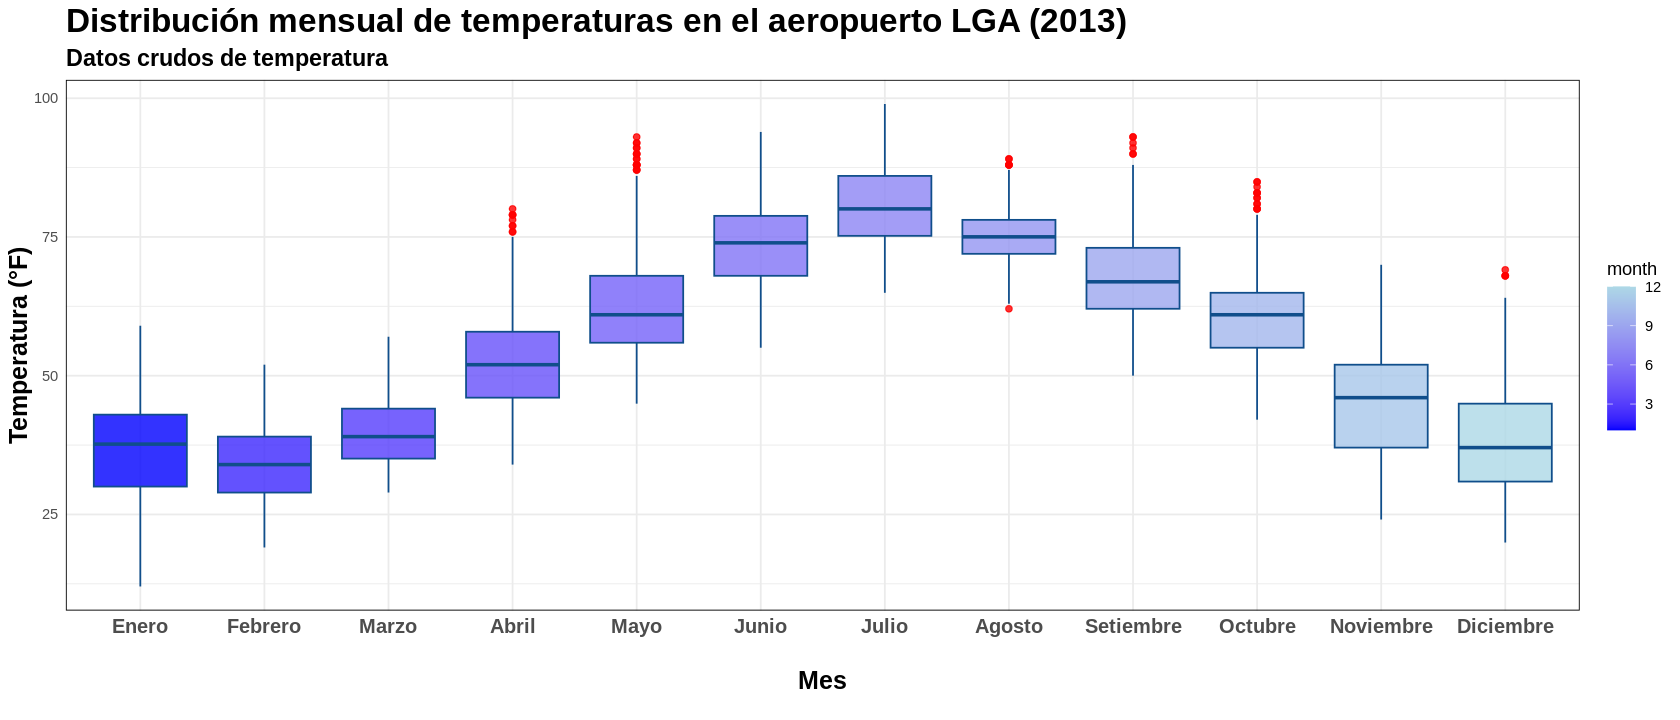

In [ ]:
# Filtrar los datos para tomar solo los de un aeropuerto específico
weather_filtered <- weather %>% filter(origin == "LGA")

# Asignar nombre del mes según el valor de month directamente
weather_filtered$mes <- ifelse(weather_filtered$month == 1, "Enero",
                         ifelse(weather_filtered$month == 2, "Febrero",
                         ifelse(weather_filtered$month == 3, "Marzo",
                         ifelse(weather_filtered$month == 4, "Abril",
                         ifelse(weather_filtered$month == 5, "Mayo",
                         ifelse(weather_filtered$month == 6, "Junio",
                         ifelse(weather_filtered$month == 7, "Julio",
                         ifelse(weather_filtered$month == 8, "Agosto",
                         ifelse(weather_filtered$month == 9, "Setiembre",
                         ifelse(weather_filtered$month == 10, "Octubre",
                         ifelse(weather_filtered$month == 11, "Noviembre",
                         ifelse(weather_filtered$month == 12, "Diciembre", "NA"))))))))))))

# Ordenar los meses
weather_filtered$mes <- factor(weather_filtered$mes,
                      levels = c("Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Setiembre",
                                 "Octubre", "Noviembre", "Diciembre"))

# Gráfico: boxplot por nombre del mes (solo para LGA)
options(repr.plot.width = 14, repr.plot.height = 6)  # Aumentar el tamaño del gráfico
ggplot(weather_filtered, aes(mes, temp)) + #Indicar los ejes x y y en el gráfico
  geom_boxplot(alpha = 0.8, color = 'dodgerblue4', outlier.shape = 19, outlier.color = 'red', aes(fill = month)) + #Estilos del gráfico
  labs(title = "Distribución mensual de temperaturas en el aeropuerto LGA (2013)",   #Indicar los títulos del gráfico
       subtitle = "Datos crudos de temperatura",
       y = "Temperatura (°F)",
       x = "Mes") +
  theme_minimal() +  # Hacerlo más simple
  scale_fill_gradient(low = "blue", high = "lightblue") + #Elegir los tonos para la escala de colores
  theme(
   #Agregarle estilos a todos los títulos
    axis.text.x = element_text(size = 12, face = "bold"),
    axis.title.x = element_text(size = 15, face = "bold", margin = margin(t = 20, b = 10)),
    axis.title.y = element_text(size = 15, face = "bold", margin = margin(t = 20, b = 10)),
    plot.title = element_text(size = 20, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "bold"),
    plot.caption = element_text(size = 10, face = "italic"),
    panel.border = element_rect(color = "black", fill = NA, size = 0.5)
  )



**DIAGRAMA DE CAJA O BLOXPLOT CON COLORES**

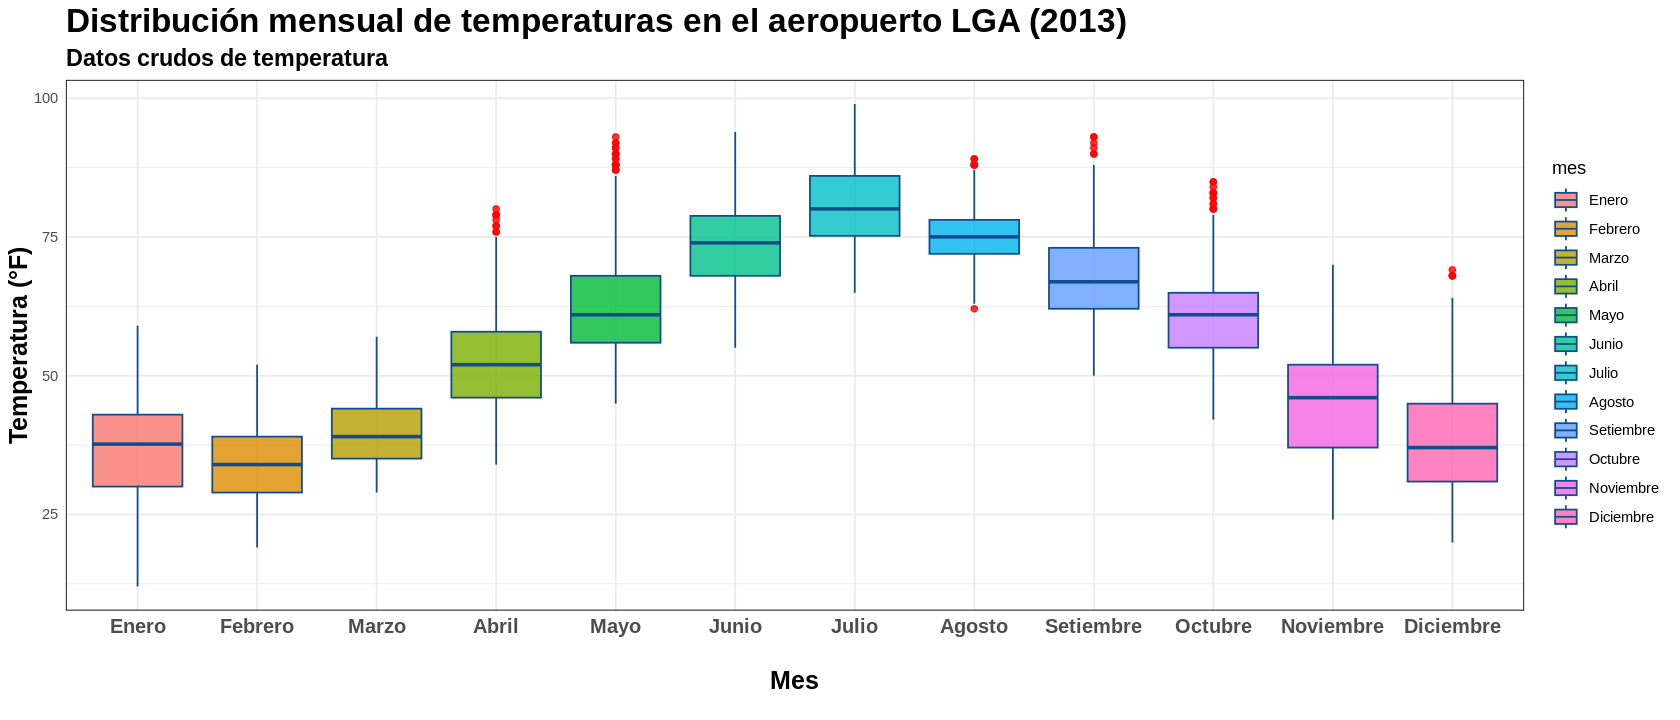

In [ ]:
# Filtrar los datos para tomar solo los de un aeropuerto específico
weather_filtered <- weather %>% filter(origin == "LGA")

# Asignar nombre del mes según el valor de month directamente
weather_filtered$mes <- ifelse(weather_filtered$month == 1, "Enero",
                         ifelse(weather_filtered$month == 2, "Febrero",
                         ifelse(weather_filtered$month == 3, "Marzo",
                         ifelse(weather_filtered$month == 4, "Abril",
                         ifelse(weather_filtered$month == 5, "Mayo",
                         ifelse(weather_filtered$month == 6, "Junio",
                         ifelse(weather_filtered$month == 7, "Julio",
                         ifelse(weather_filtered$month == 8, "Agosto",
                         ifelse(weather_filtered$month == 9, "Setiembre",
                         ifelse(weather_filtered$month == 10, "Octubre",
                         ifelse(weather_filtered$month == 11, "Noviembre",
                         ifelse(weather_filtered$month == 12, "Diciembre", "NA"))))))))))))

# Ordenar los meses
weather_filtered$mes <- factor(weather_filtered$mes,
                      levels = c("Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Setiembre",
                                 "Octubre", "Noviembre", "Diciembre"))

# Gráfico: boxplot por nombre del mes (solo para LGA)
options(repr.plot.width = 14, repr.plot.height = 6)  # Aumentar el tamaño del gráfico
ggplot(weather_filtered, aes(mes, temp,  fill = mes)) + #Indicar los ejes x y y en el gráfico
  geom_boxplot(alpha = 0.8, color = 'dodgerblue4', outlier.shape = 19, outlier.color = 'red') + #Estilos del gráfico
  labs(title = "Distribución mensual de temperaturas en el aeropuerto LGA (2013)",   #Indicar los títulos del gráfico
       subtitle = "Datos crudos de temperatura",
       y = "Temperatura (°F)",
       x = "Mes") +
  theme_minimal() +  # Hacerlo más simple
  theme(
   #Agregarle estilos a todos los títulos
    axis.text.x = element_text(size = 12, face = "bold"),
    axis.title.x = element_text(size = 15, face = "bold", margin = margin(t = 20, b = 10)),
    axis.title.y = element_text(size = 15, face = "bold", margin = margin(t = 20, b = 10)),
    plot.title = element_text(size = 20, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "bold"),
    plot.caption = element_text(size = 10, face = "italic"),
    panel.border = element_rect(color = "black", fill = NA, size = 0.5)
  )


**DIAGRAMA DE VIOLINPLOT**

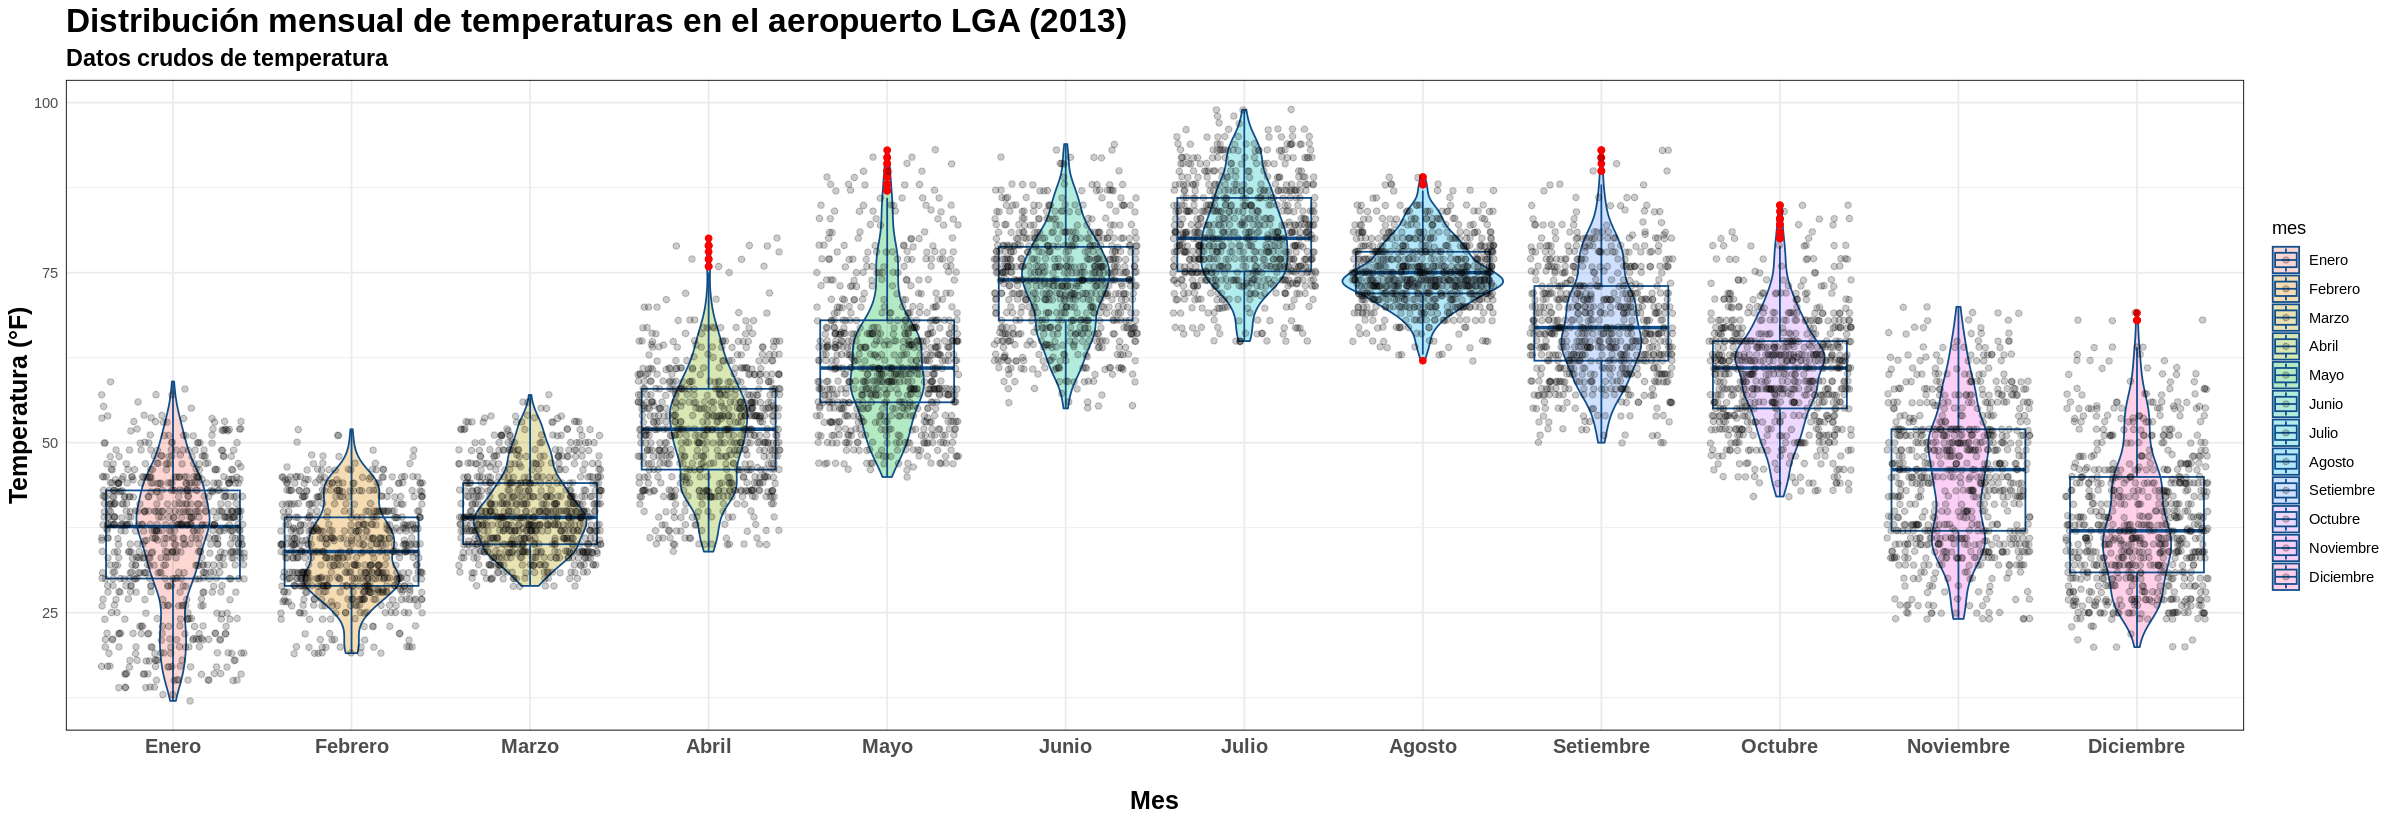

In [ ]:
# Filtrar los datos para tomar solo los de un aeropuerto específico
weather_filtered <- weather %>% filter(origin == "LGA")

# Asignar nombre del mes según el valor de month directamente
weather_filtered$mes <- ifelse(weather_filtered$month == 1, "Enero",
                         ifelse(weather_filtered$month == 2, "Febrero",
                         ifelse(weather_filtered$month == 3, "Marzo",
                         ifelse(weather_filtered$month == 4, "Abril",
                         ifelse(weather_filtered$month == 5, "Mayo",
                         ifelse(weather_filtered$month == 6, "Junio",
                         ifelse(weather_filtered$month == 7, "Julio",
                         ifelse(weather_filtered$month == 8, "Agosto",
                         ifelse(weather_filtered$month == 9, "Setiembre",
                         ifelse(weather_filtered$month == 10, "Octubre",
                         ifelse(weather_filtered$month == 11, "Noviembre",
                         ifelse(weather_filtered$month == 12, "Diciembre", "NA"))))))))))))

# Ordenar los meses
weather_filtered$mes <- factor(weather_filtered$mes,
                      levels = c("Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Setiembre",
                                 "Octubre", "Noviembre", "Diciembre"))

# Gráfico: boxplot por nombre del mes (solo para LGA)
options(repr.plot.width = 20, repr.plot.height = 7)  # Aumentar el tamaño del gráfico
ggplot(weather_filtered, aes(mes, temp, fill = mes)) + #Indicar los ejes x y y en el gráfico
  geom_violin(alpha = 0.3, color = 'dodgerblue4') + #ViolinPlot
  geom_boxplot(alpha = 0, outlier.shape = 19,color = 'dodgerblue4', outlier.color = 'red', outlier.alpha = 1) + #Boxplot
  geom_jitter(width = 0.4, alpha = 0.2) + #Agregar estilos a los puntos
  labs(title = "Distribución mensual de temperaturas en el aeropuerto LGA (2013)",   #Indicar los títulos del gráfico
       subtitle = "Datos crudos de temperatura",
       y = "Temperatura (°F)",
       x = "Mes") +
  theme_minimal() +  # Hacerlo más simple
  theme(
   #Agregarle estilos a todos los títulos
    axis.text.x = element_text(size = 12, face = "bold"),
    axis.title.x = element_text(size = 15, face = "bold", margin = margin(t = 20, b = 10)),
    axis.title.y = element_text(size = 15, face = "bold", margin = margin(t = 20, b = 10)),
    plot.title = element_text(size = 20, face = "bold"),
    plot.subtitle = element_text(size = 14, face = "bold"),
    plot.caption = element_text(size = 10, face = "italic"),
    panel.border = element_rect(color = "black", fill = NA, size = 0.5)
  )

## 1) **Grafico de Barras Verticales **

---

Este gráfico muestra la cantidad total de vuelos por mes en el año 2013 desde los aeropuertos de Nueva York, utilizando los datos del paquete nycflights13.

En el eje horizontal se presentan los meses del año, desde enero hasta diciembre, y en el eje vertical se observa el número de vuelos registrados. Las barras están ordenadas cronológicamente y coloreadas con un degradado azul


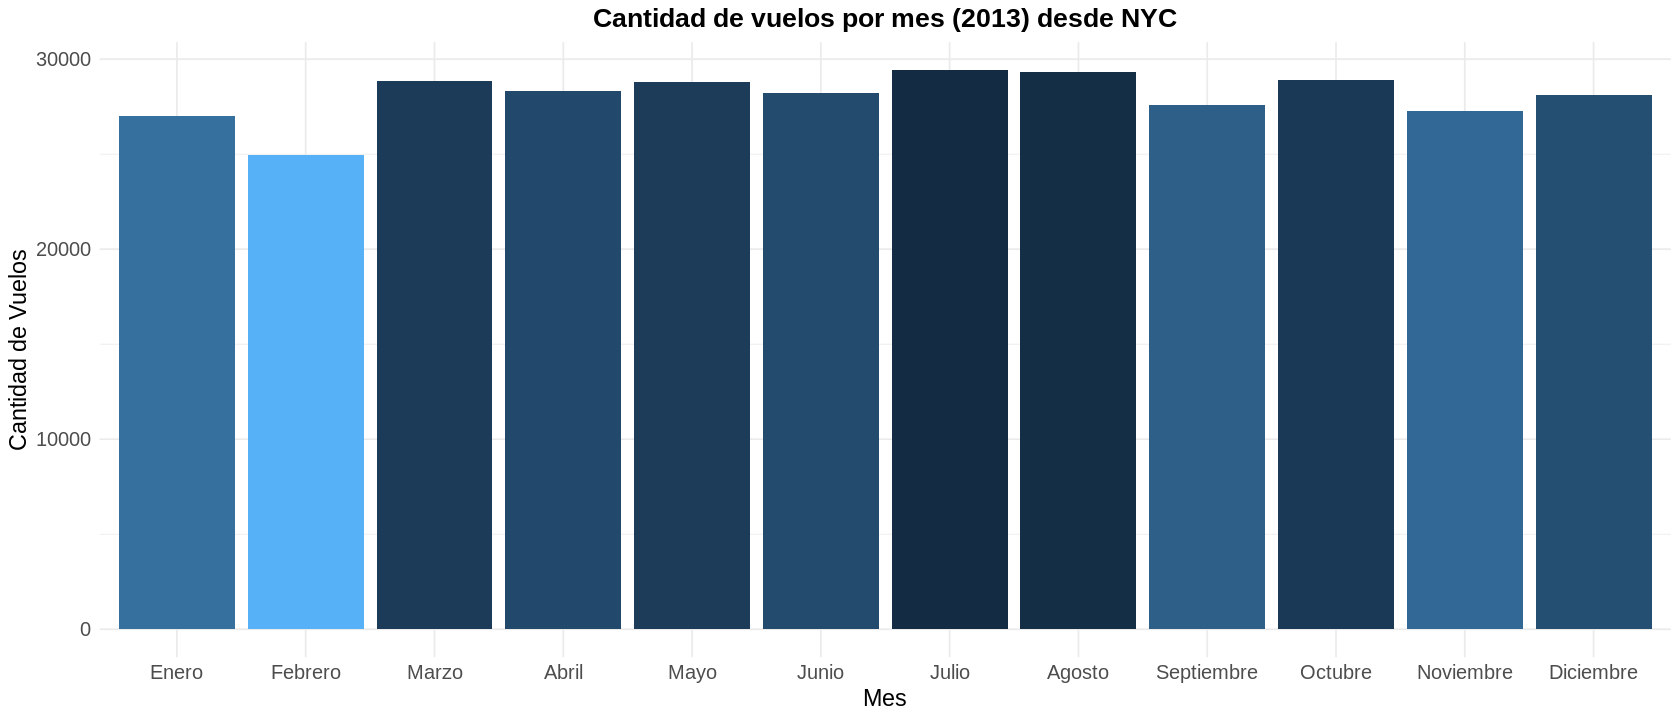

In [ ]:

# Crear vector con nombres de los meses
nombres_meses <- c("Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                   "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre")

# Agrupar y contar vuelos por mes
vuelos_por_mes <- flights %>%
  group_by(month) %>%
  summarise(total_vuelos = n()) %>%
  mutate(mes_nombre = factor(nombres_meses[month], levels = nombres_meses))

# Gráfico de barras verticales con degradado y nombres de meses
options(repr.plot.width = 14, repr.plot.height = 6)
ggplot(vuelos_por_mes, aes(x = mes_nombre, y = total_vuelos, fill = total_vuelos)) +
  geom_bar(stat = "identity") +
  scale_fill_gradient(low = "#56B1F7", high = "#132B43") +
  labs(
    title = "Cantidad de vuelos por mes (2013) desde NYC",
    x = "Mes",
    y = "Cantidad de Vuelos"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14),
    legend.position = "none"
  )

# 2) **Gráfico lollipops**
El gráfico muestra la cantidad total de vuelos registrados por mes en el año 2013 desde la ciudad de Nueva York. Cada punto representa el total de vuelos en un mes específico, este análisis permite identificar patrones estacionales en el tráfico aéreo, como posibles aumentos en verano o durante periodos vacacionales.

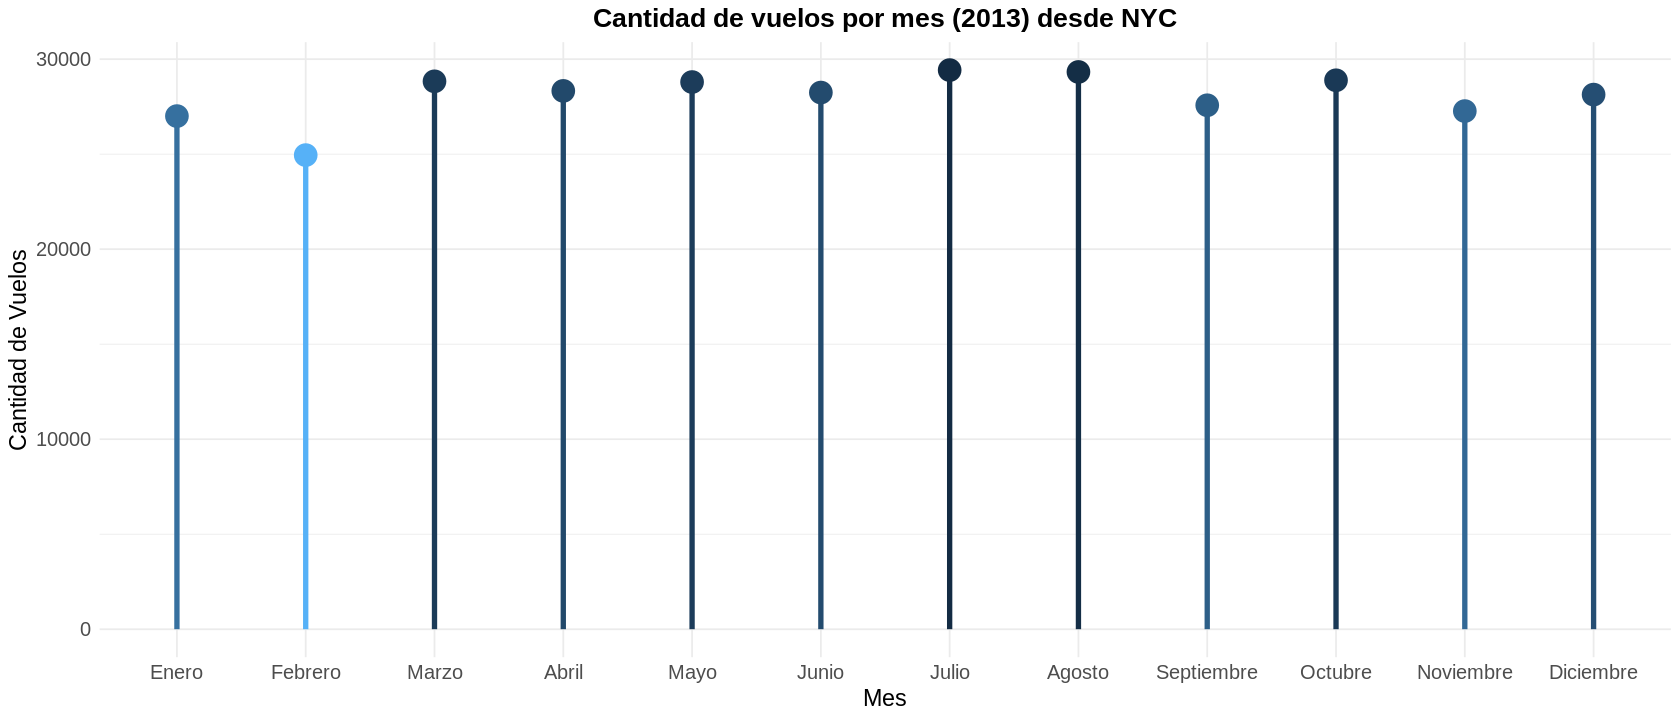

In [ ]:
vuelos_por_mes <- flights %>%
  group_by(month) %>%
  summarise(total_vuelos = n())

options(repr.plot.width = 14, repr.plot.height = 6)
ggplot(vuelos_por_mes, aes(x = factor(month), y = total_vuelos, color = total_vuelos)) +
  geom_segment(aes(x = factor(month), xend = factor(month), y = 0, yend = total_vuelos), linewidth = 1.5) +
  geom_point(size = 6) +
  scale_color_gradient(low = "#56B1F7", high = "#132B43") +
  scale_x_discrete(labels = c("Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                              "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre")) +
  labs(
    title = "Cantidad de vuelos por mes (2013) desde NYC",
    x = "Mes",
    y = "Cantidad de Vuelos"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    axis.text = element_text(size = 12),
    axis.text.x = element_text(angle = 0, hjust = 0.5),
    axis.title = element_text(size = 14),
    legend.position = "none"
  )


# 3) Gráfico de barras horizontal

Este gráfico de barras horizontal muestra la **distancia promedio recorrida por vuelos** de **seis aerolíneas distintas** durante el año 2013. Cada barra representa una aerolínea, identificada por su **nombre completo**, y la longitud de la barra indica cuántas millas recorren sus vuelos en promedio. Las aerolíneas fueron seleccionadas de forma **aleatoria**, y los colores permiten diferenciarlas visualmente. El gráfico facilita la comparación de trayectos promedio entre estas aerolíneas.

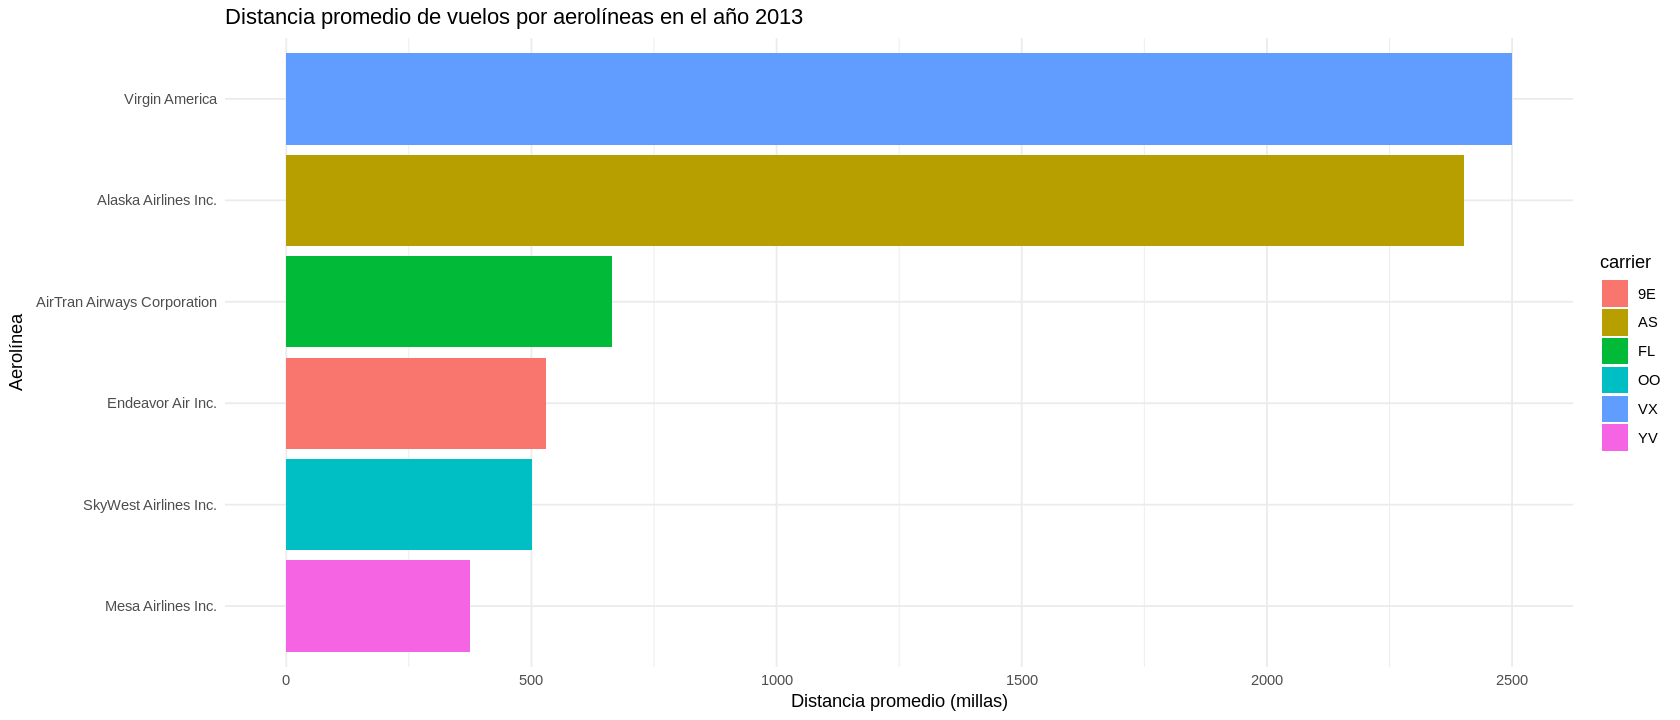

In [ ]:
# Agrupamos por carrier y calculamos la distancia promedio
avg_distance <- flights %>%
  group_by(carrier) %>%
  summarise(avg_distance = mean(distance, na.rm = TRUE)) %>%
  arrange(desc(avg_distance))

# Seleccionamos 6 aerolíneas aleatorias
set.seed(123)
random_carriers <- sample(avg_distance$carrier, 6)

# Filtramos el dataframe con las aerolíneas seleccionadas
avg_distance_sample <- avg_distance %>%
  filter(carrier %in% random_carriers) %>%
  left_join(airlines, by = "carrier")

# Gráfico de barras horizontal con nombres de aerolínea
options(repr.plot.width = 14, repr.plot.height = 6)
ggplot(avg_distance_sample, aes(x = reorder(name, avg_distance), y = avg_distance, fill = carrier)) +
  geom_col(position = "dodge") +
  coord_flip() +
  labs(title = "Distancia promedio de vuelos por aerolíneas en el año 2013",
       x = "Aerolínea",
       y = "Distancia promedio (millas)") +
  theme_minimal()


# 4) Gráfico de radar

Este gráfico tipo radar (o gráfico circular de barras) muestra la distancia promedio recorrida por vuelos de seis aerolíneas seleccionadas aleatoriamente en el año 2013. Cada segmento circular representa una aerolínea, identificada por su nombre completo, y la longitud del segmento indica la cantidad promedio de millas recorridas por sus vuelos. Este tipo de visualización permite comparar de manera visual la magnitud de las distancias recorridas entre las aerolíneas, destacando aquellas que operan vuelos más largos.

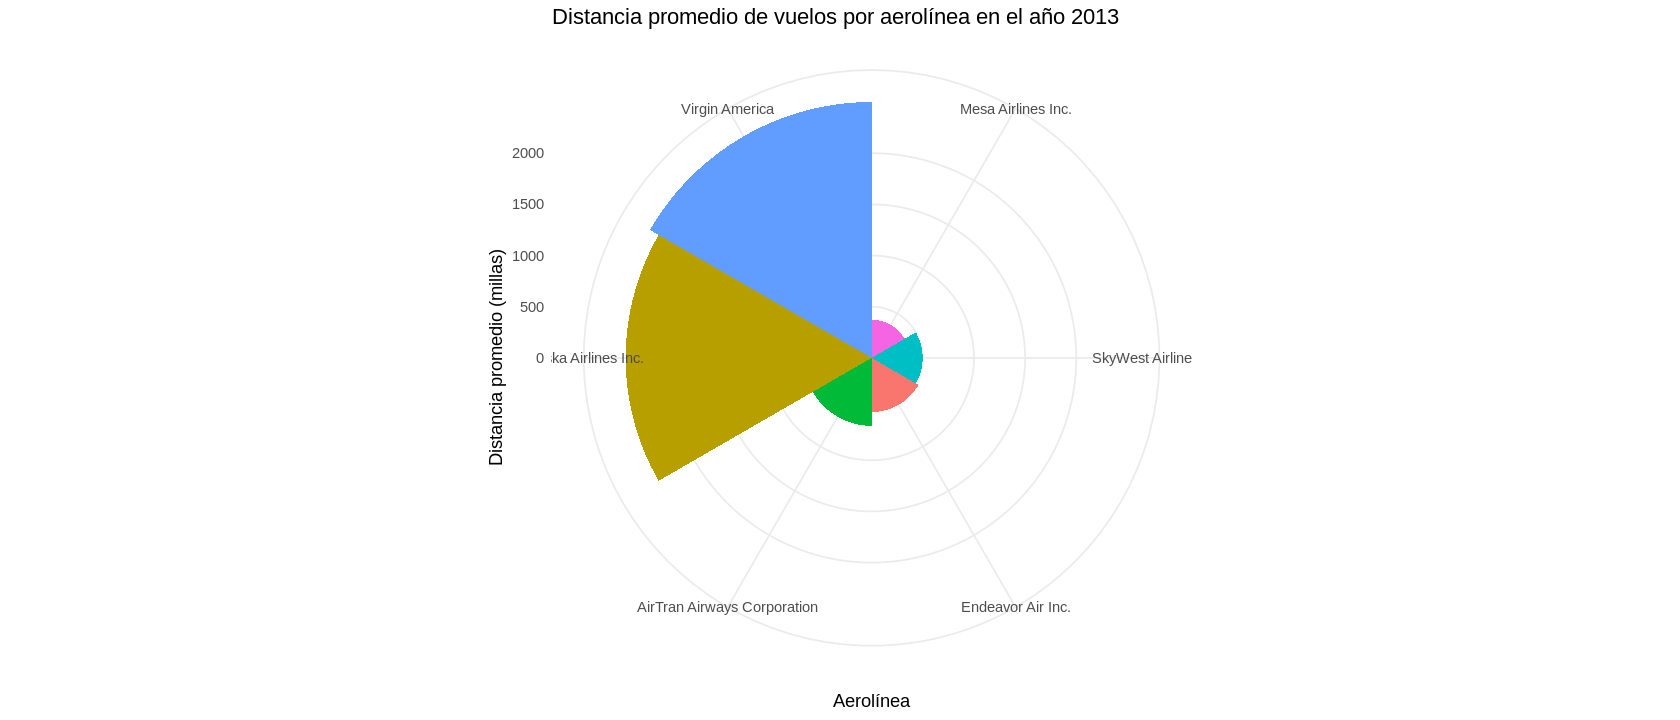

In [ ]:
# Paso 1: Calcular distancia promedio por aerolínea
avg_distance <- flights %>%
  group_by(carrier) %>%
  summarise(avg_distance = mean(distance, na.rm = TRUE)) %>%
  arrange(desc(avg_distance))

# Paso 2: Seleccionar 6 aerolíneas aleatorias
set.seed(123)
random_carriers <- sample(avg_distance$carrier, 6)

# Paso 3: Filtrar y unir con los nombres de aerolínea
avg_distance_sample <- avg_distance %>%
  filter(carrier %in% random_carriers) %>%
  left_join(airlines, by = "carrier")

# Paso 4: Gráfico radar
options(repr.plot.width = 14, repr.plot.height = 6)
ggplot(data = avg_distance_sample) +
  geom_col(
    mapping = aes(x = reorder(name, avg_distance), y = avg_distance, fill = carrier),
    show.legend = FALSE,
    width = 1
  ) +
  coord_polar() +
  theme_minimal() +
  theme(aspect.ratio = 1) +
  labs(title = "Distancia promedio de vuelos por aerolínea en el año 2013",
       x = "Aerolínea",
       y = "Distancia promedio (millas)")


# 5) Gráfico de Pastel y Dona


**Descripción:**

Los gráficos de pastel y dona representan la proporción de vuelos operados por cada aerolínea en el conjunto de datos nycflights13 para el año 2013 en Nueva York.

In [ ]:
if (!require("dplyr")) install.packages("dplyr")
install.packages('nycflights13')
#Librería de la BD
library(nycflights13)
library(dplyr)
#Instalación de paquetes para el uso de gráficos
if (!require("ggplot2")) install.packages("ggplot2")  #Para el grafico de BoxPlot
if (!require("dplyr")) install.packages("dplyr")    #Para el grafico de BoxPlot y ViolinPlot(Función de filtrado)
if (!require("scales")) install.packages("scales")   #Para el grafico de lollipops
if (!require("fmsb")) install.packages("fmsb")     #Para el grafico de radar
if (!require("forcats")) install.packages("forcats")
if (!require("patchwork")) install.packages("patchwork")
flights_grouped <- your_dataframe %>%
   mutate(
     carrier_group = case_when(
       carrier %in% c("AA","DL","UA","WN") ~ carrier,
       TRUE                                 ~ "Otros"
     )
   ) %>%
   count(carrier_group) %>%
   mutate(porcentaje = n / sum(n) * 100)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



ERROR: Error: object 'your_dataframe' not found


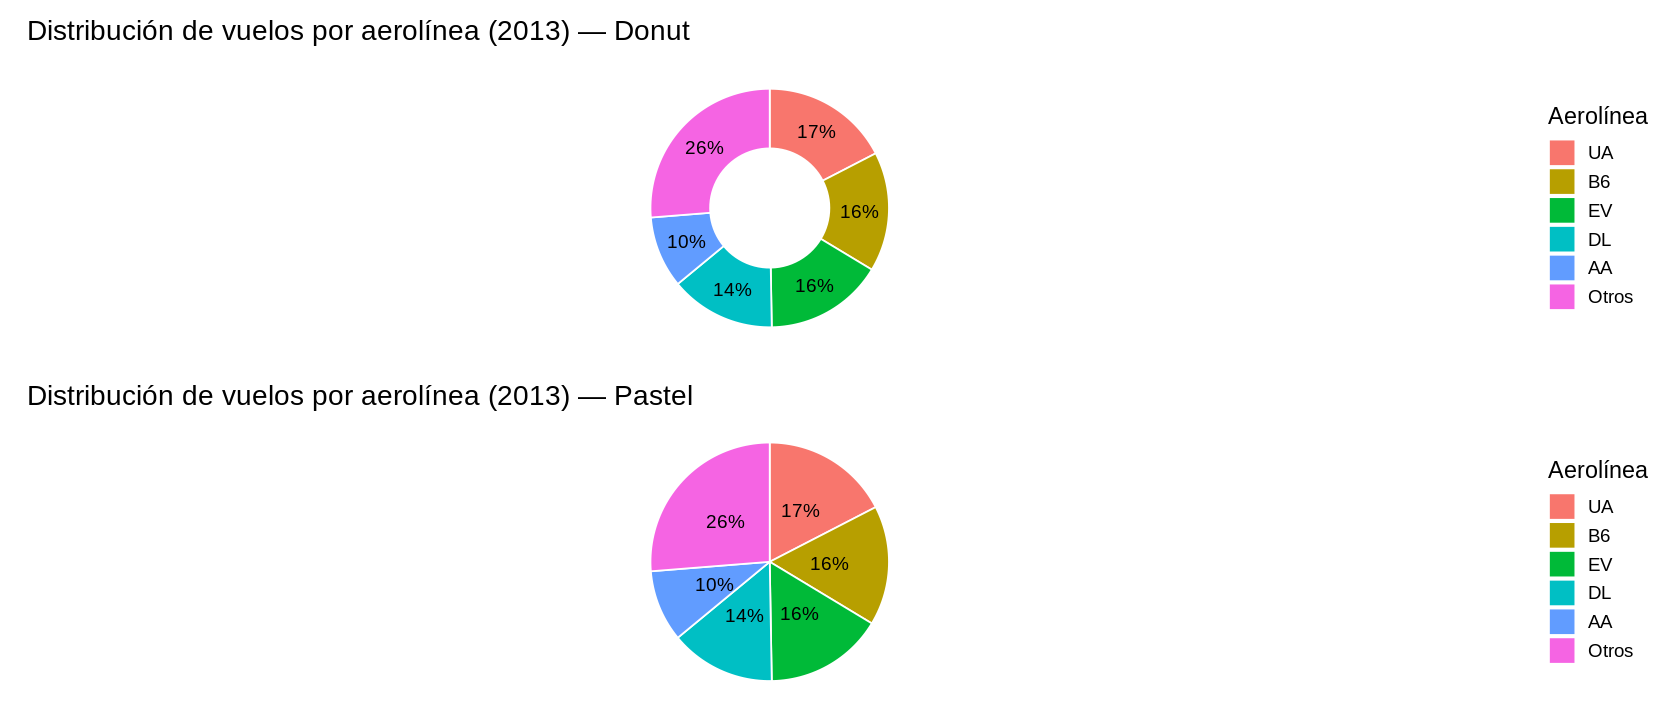

In [ ]:
# 1. Librerías
library(dplyr)
library(forcats)
library(ggplot2)
library(patchwork)

# Before using flights_grouped, create it:
# Calculate the percentage of flights for each carrier
flights_grouped <- flights %>%
  group_by(carrier) %>%
  summarise(count = n()) %>%
  mutate(porcentaje = count / sum(count) * 100,
         carrier_group = carrier)

# 2. Agrupar aerolíneas: conservar 5 más grandes, resto como "Otros"
flights_grouped <- flights_grouped %>%
  arrange(desc(porcentaje)) %>%
  mutate(
    carrier_group = if_else(row_number() <= 5, as.character(carrier_group), "Otros")
  ) %>%
  group_by(carrier_group) %>%
  summarise(porcentaje = sum(porcentaje), .groups = "drop")

# 3. Ordenar factor y calcular posiciones
flights_grouped <- flights_grouped %>%
  mutate(
    carrier_group = fct_reorder(carrier_group, porcentaje, .desc = TRUE),
    carrier_group = fct_relevel(carrier_group, "Otros", after = Inf)
  ) %>%
  arrange(carrier_group) %>%
  mutate(
    ymin = cumsum(lag(porcentaje, default = 0)),
    ymax = cumsum(porcentaje)
  )

# 4. Donut
p_donut <- ggplot(flights_grouped, aes(fill = carrier_group)) +
  geom_rect(aes(xmin = 3, xmax = 4, ymin = ymin, ymax = ymax),
            color = "white") +
  coord_polar(theta = "y", start = 0, direction = 1) +
  xlim(c(2, 4)) +
  geom_text(aes(x = 3.5, y = (ymin + ymax) / 2,
                label = paste0(round(porcentaje), "%")),
            size = 4) +
  labs(title = "Distribución de vuelos por aerolínea (2013) — Donut",
       fill  = "Aerolínea") +
  theme_minimal(base_size = 14) +
  theme(axis.text = element_blank(),
        axis.title = element_blank(),
        panel.grid = element_blank())

# 5. Pastel con mismas coordenadas y etiquetas en el centro

p_pie <- ggplot(flights_grouped, aes(fill = carrier_group)) +
  geom_rect(aes(xmin = 0, xmax = 1, ymin = ymin, ymax = ymax),
            color = "white") +
  coord_polar(theta = "y", start = 0) +
  geom_text(aes(x = 0.5, y = (ymin + ymax) / 2,
                label = paste0(round(porcentaje), "%")),
            size = 4) +
  labs(title = "Distribución de vuelos por aerolínea (2013) — Pastel",
       fill  = "Aerolínea") +
  theme_void(base_size = 14) +
  theme(legend.position = "right")

# 6. Combinar en FILAS y agranda el lienzo al guardar
vertical_layout <- p_donut / p_pie +
  plot_layout(heights = c(1, 1))

# 7. Mostrar en pantalla
print(vertical_layout)


